# A List of Heatmaps

The main feature of **complexheatmap** is that it supports concatenating a list of heatmaps and annotations horizontally or vertically, making it possible to visualize associations from various sources of information.

For horizontal concatenation, all heatmaps must have the same number of rows. The first heatmap (by default) is the "main heatmap" that controls global row ordering.

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import (
    Heatmap, HeatmapList, HeatmapAnnotation, rowAnnotation,
    anno_barplot, anno_boxplot, color_ramp2
)
import grid_py as gp

## Setup: Three matrices

We create three matrices that share the same 12 rows (e.g., genes). The third is a character vector treated as a one-column heatmap.

In [2]:
np.random.seed(123)

mat1 = np.vstack([
    np.random.normal(2, 1, (8, 10)),
    np.random.normal(-2, 1, (4, 10))
])

mat2 = np.vstack([
    np.random.uniform(1, 3, (6, 10)),
    np.random.uniform(0, 2, (6, 10))
])

le = np.random.choice(["a", "b", "c"], size=12)

# Shuffle consistently
ind = np.random.permutation(12)
mat1 = mat1[ind]
mat2 = mat2[ind]
le = le[ind]

print(f"mat1: {mat1.shape}, mat2: {mat2.shape}, le: {le.shape}")

mat1: (12, 10), mat2: (12, 10), le: (12,)


## Concatenation with the `+` operator

Simply use `+` to concatenate heatmaps. The result is a `HeatmapList` object. By default, dendrograms from the second and subsequent heatmaps are removed, and all share the row order of the first (main) heatmap.

Type: HeatmapList


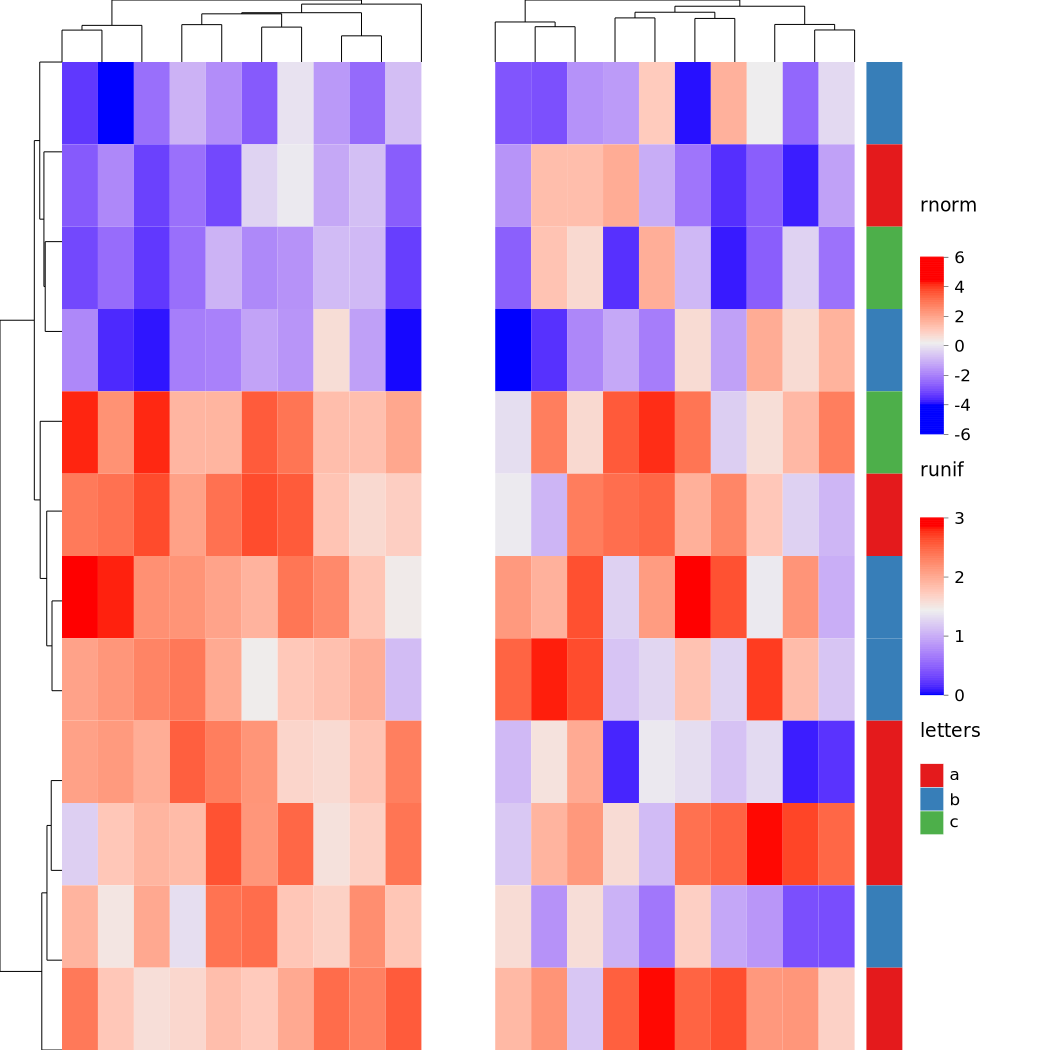

HeatmapList(['rnorm', 'runif', 'letters'], direction='horizontal')

In [3]:
ht1 = Heatmap(mat1, name="rnorm")
ht2 = Heatmap(mat2, name="runif")
ht3 = Heatmap(le, name="letters")

ht_list = ht1 + ht2 + ht3
print(f"Type: {type(ht_list).__name__}")
ht_list.draw()

## Verifying the `+` operator

The `+` operator produces a `HeatmapList`. We can inspect its layout and orders.

In [4]:
ht1 = Heatmap(np.random.randn(10, 5), name="ht1")
ht2 = Heatmap(np.random.randn(10, 3), name="ht2")
ht_list = ht1 + ht2

print(f"Is HeatmapList: {isinstance(ht_list, HeatmapList)}")

ht_list.make_layout()
row_orders = ht_list.get_row_order()
col_orders = ht_list.get_column_order()

print(f"Row orders keys: {list(row_orders.keys())}")
print(f"Col orders keys: {list(col_orders.keys())}")
print(f"Row order ht1 length: {len(row_orders['ht1'])}")
print(f"Col order ht1 length: {len(col_orders['ht1'])}")
print(f"Col order ht2 length: {len(col_orders['ht2'])}")

Is HeatmapList: True
Row orders keys: ['ht1', 'ht2']
Col orders keys: ['ht1', 'ht2']
Row order ht1 length: 10
Col order ht1 length: 5
Col order ht2 length: 3


## Explicit HeatmapList construction

You can also build a `HeatmapList` explicitly and add heatmaps one by one. This is useful when constructing in a loop.

In [5]:
hl = HeatmapList()
hl.add_heatmap(Heatmap(mat1, name="exp1"))
hl.add_heatmap(Heatmap(mat2, name="exp2"))
hl.make_layout()

ro = hl.get_row_order()
print(f"Number of heatmaps: {len(ro)}")
print(f"Heatmap names: {list(ro.keys())}")

Number of heatmaps: 2
Heatmap names: ['exp1', 'exp2']


## Titles for the Heatmap List

Global `row_title` and `column_title` are set in the `draw()` method, which acts as a title spanning all heatmaps.

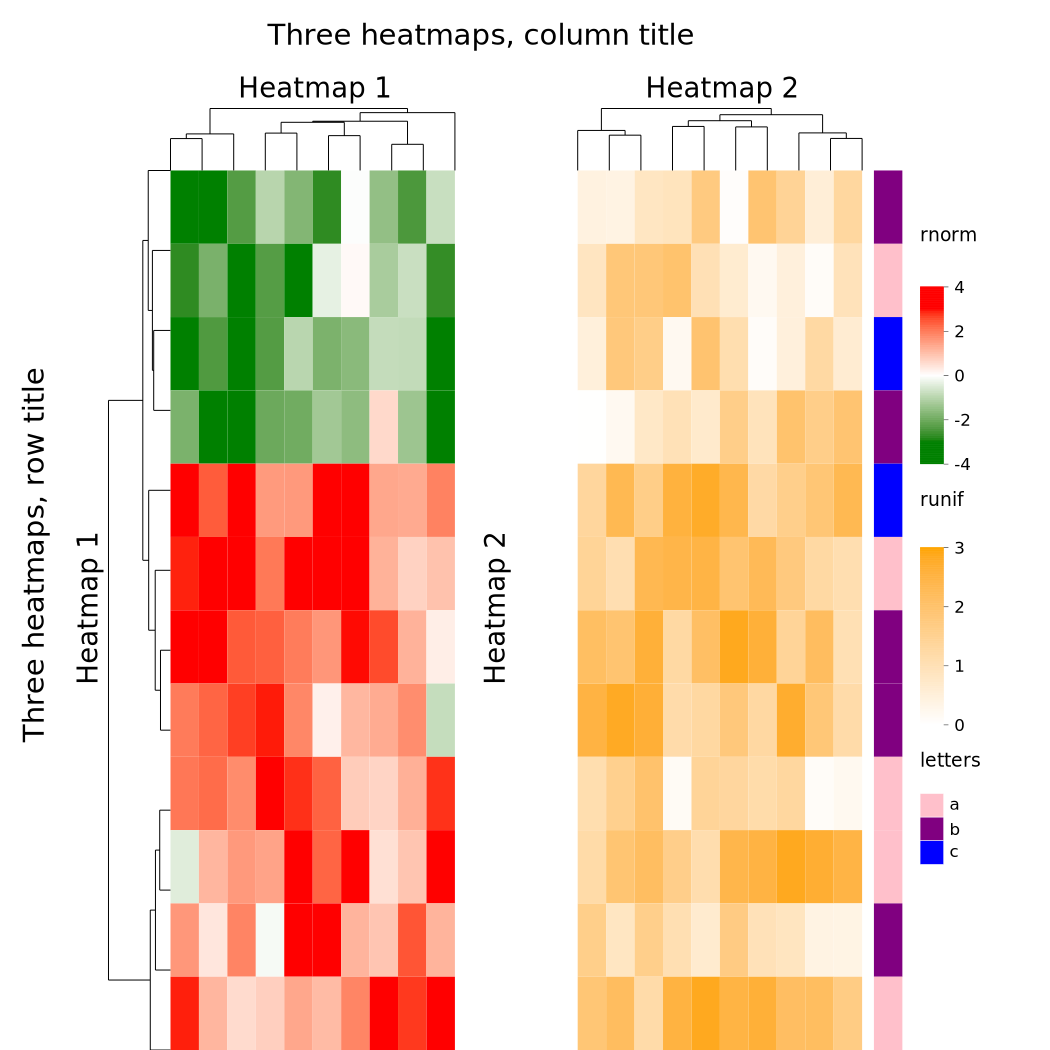

HeatmapList(['rnorm', 'runif', 'letters'], direction='horizontal')

In [6]:
col_rnorm = color_ramp2([-3, 0, 3], ["green", "white", "red"])
col_runif = color_ramp2([0, 3], ["white", "orange"])
col_letters = {"a": "pink", "b": "purple", "c": "blue"}

ht1 = Heatmap(mat1, name="rnorm", col=col_rnorm,
              row_title="Heatmap 1", column_title="Heatmap 1")
ht2 = Heatmap(mat2, name="runif", col=col_runif,
              row_title="Heatmap 2", column_title="Heatmap 2")
ht3 = Heatmap(le, name="letters", col=col_letters)

ht_list = ht1 + ht2 + ht3
ht_list.draw(             row_title="Three heatmaps, row title",
             column_title="Three heatmaps, column title")

## Gap Between Heatmaps

The `ht_gap` argument in `draw()` controls spacing between heatmaps.

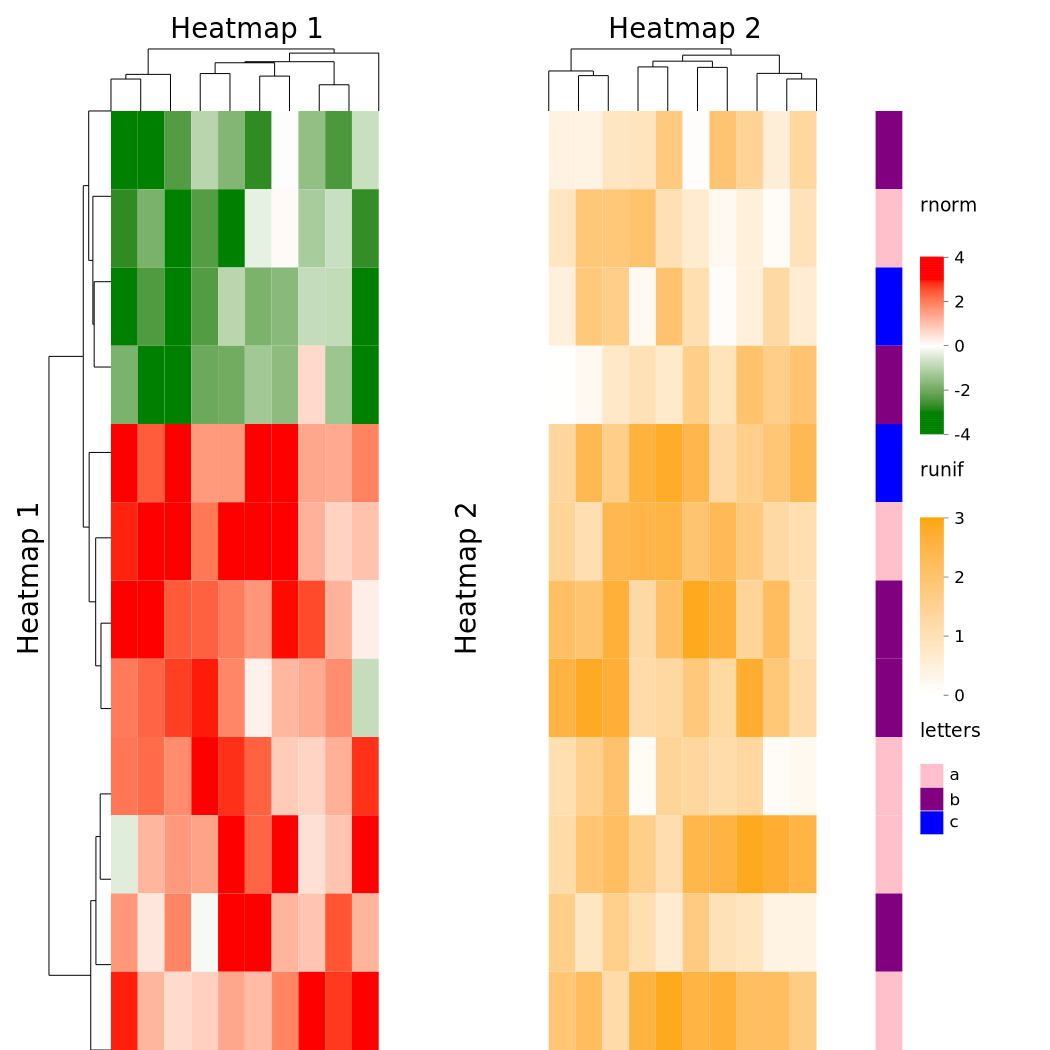

HeatmapList(['rnorm', 'runif', 'letters'], direction='horizontal')

In [7]:
ht_list = ht1 + ht2 + ht3
ht_list.draw(ht_gap=10)

## Main Heatmap

By default, the first heatmap is the "main" heatmap that drives global row ordering. All other heatmaps follow its row order. If the main heatmap is split by rows, all others are split accordingly.

You can change the main heatmap with `main_heatmap` in `draw()`.

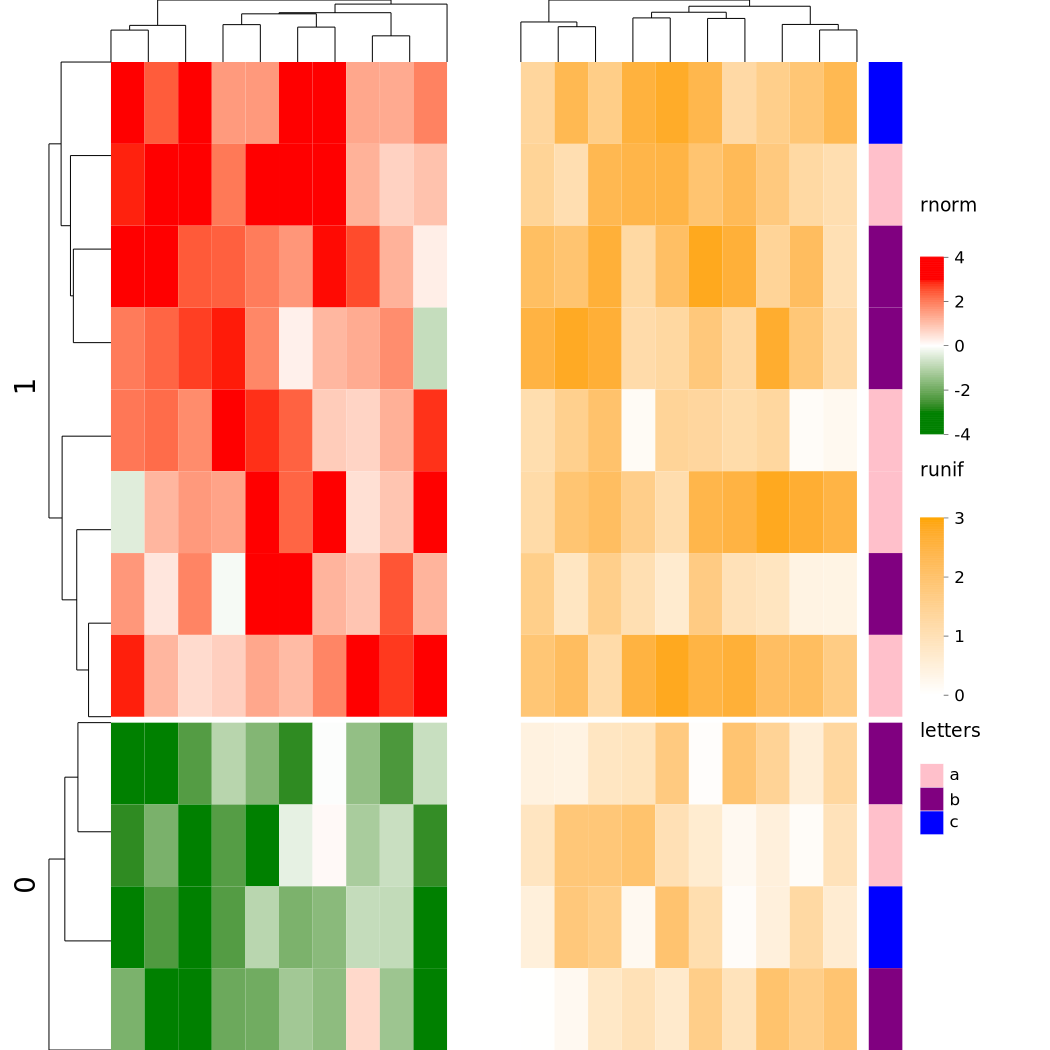

HeatmapList(['rnorm', 'runif', 'letters'], direction='horizontal')

In [8]:
ht1 = Heatmap(mat1, name="rnorm", col=col_rnorm, row_km=2)
ht2 = Heatmap(mat2, name="runif", col=col_runif)
ht3 = Heatmap(le, name="letters", col=col_letters)

# ht1 is main (default), row_km=2 splits all heatmaps
ht_list = ht1 + ht2 + ht3
ht_list.draw()

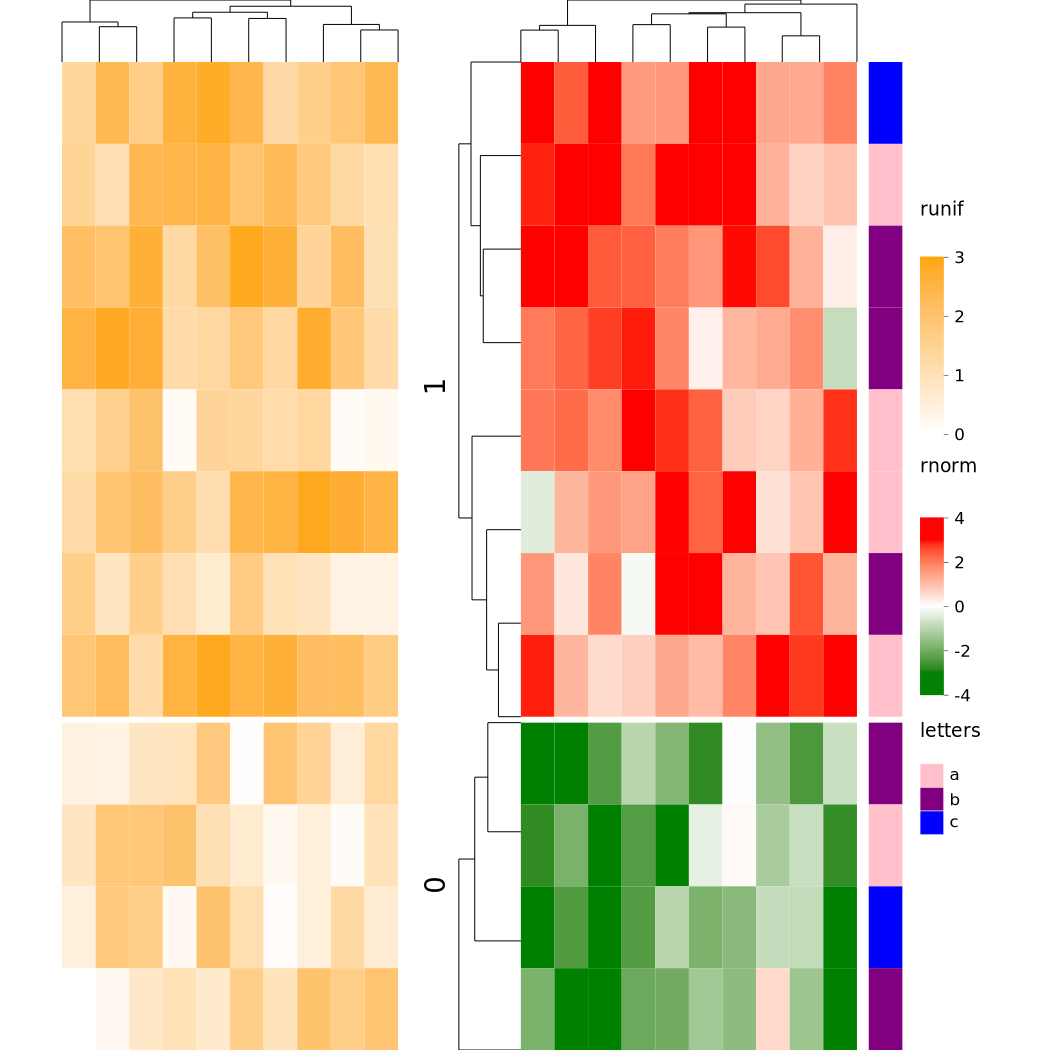

HeatmapList(['runif', 'rnorm', 'letters'], direction='horizontal')

In [9]:
# Change main heatmap to 'runif'
ht_list = ht2 + ht1 + ht3
ht_list.draw(main_heatmap="rnorm")

## Row Order Consistency

All heatmaps in the list share the same row ordering. Let's verify this.

In [10]:
np.random.seed(42)
m1 = np.random.randn(15, 6)
m2 = np.random.randn(15, 4)

h1 = Heatmap(m1, name="main")
h2 = Heatmap(m2, name="side", cluster_rows=False)
hl = h1 + h2
hl.make_layout()

ro = hl.get_row_order()
print(f"main row order length: {len(ro['main'])}")
print(f"side row order length: {len(ro['side'])}")
print(f"Both have 15 rows: {len(ro['main']) == len(ro['side']) == 15}")

main row order length: 15
side row order length: 15
Both have 15 rows: True


## Concatenate with Annotations

Row annotations can be concatenated to the heatmap list using `+`.

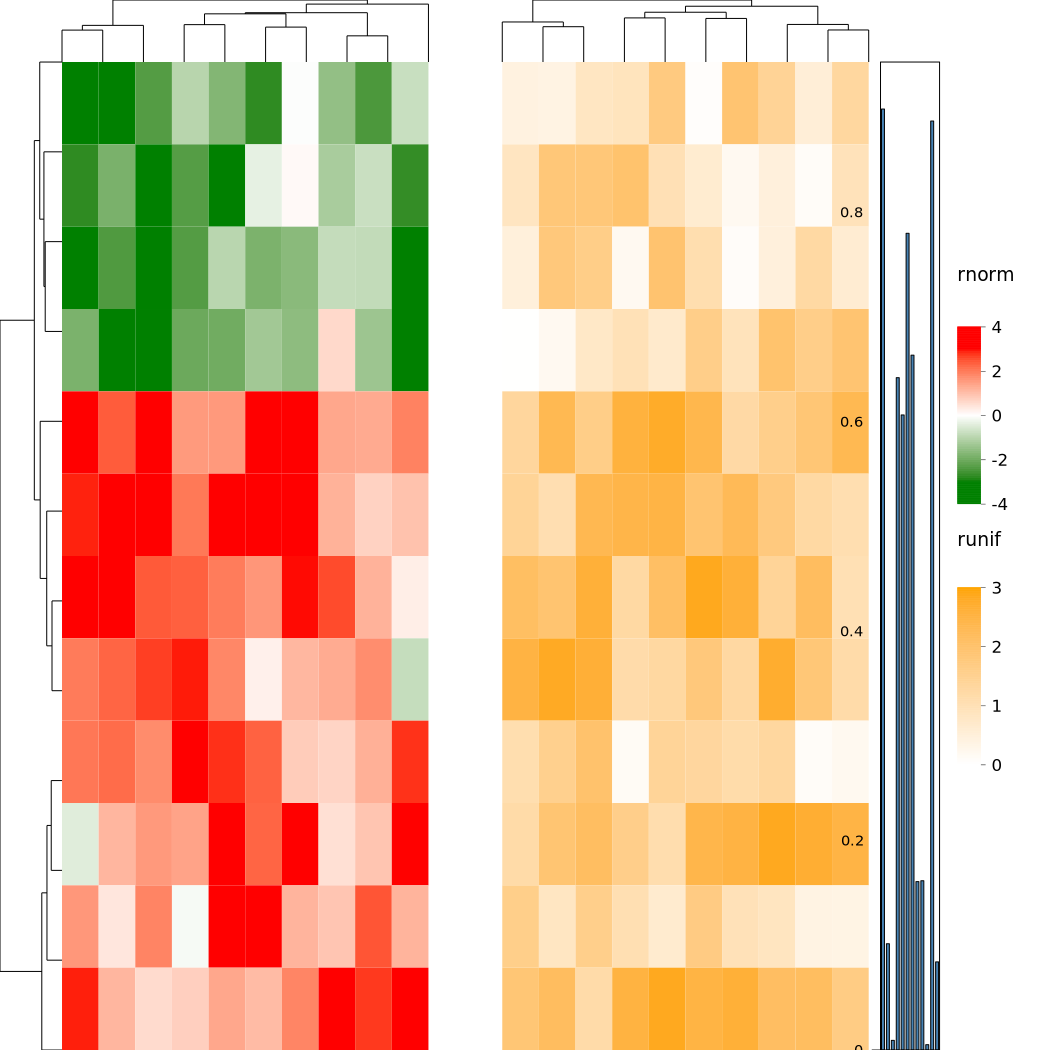

HeatmapList(['rnorm', 'runif', 'heatmap_annotation_0'], direction='horizontal')

In [11]:
ht1 = Heatmap(mat1, name="rnorm", col=col_rnorm)
ht2 = Heatmap(mat2, name="runif", col=col_runif)
ra = rowAnnotation(bar=anno_barplot(np.random.rand(12)))

ht_list = ht1 + ht2 + ra
ht_list.draw()

## Size of Heatmaps

The `width` argument in `Heatmap` controls the width of the heatmap body. It can be a numeric value (relative) or set to specific dimensions.

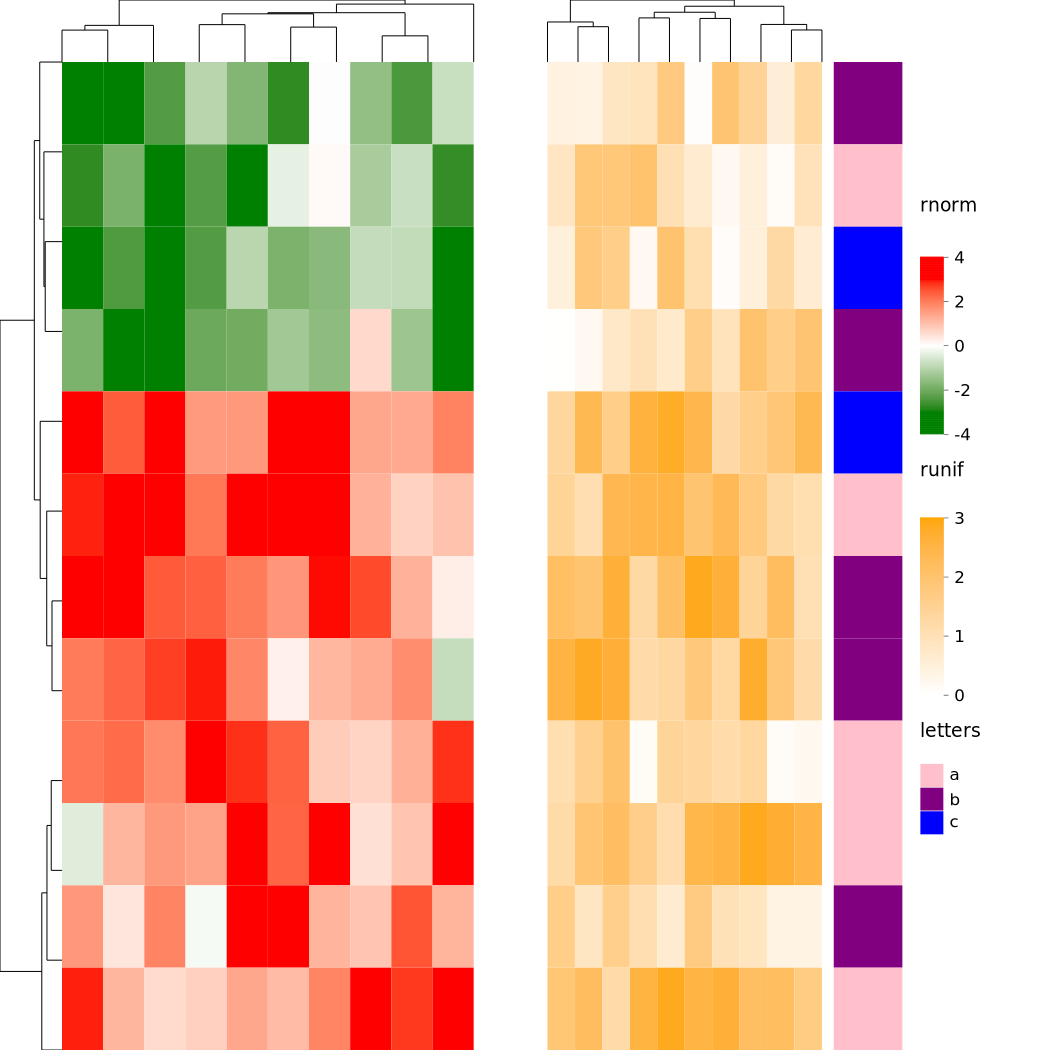

HeatmapList(['rnorm', 'runif', 'letters'], direction='horizontal')

In [12]:
ht1 = Heatmap(mat1, name="rnorm", col=col_rnorm, width=6)
ht2 = Heatmap(mat2, name="runif", col=col_runif, width=4)
ht3 = Heatmap(le, name="letters", col=col_letters, width=1)

ht_list = ht1 + ht2 + ht3
ht_list.draw()

## Building a List in a Loop

`None` can be added to a heatmap list, which is convenient when building lists in a loop.

Type: HeatmapList


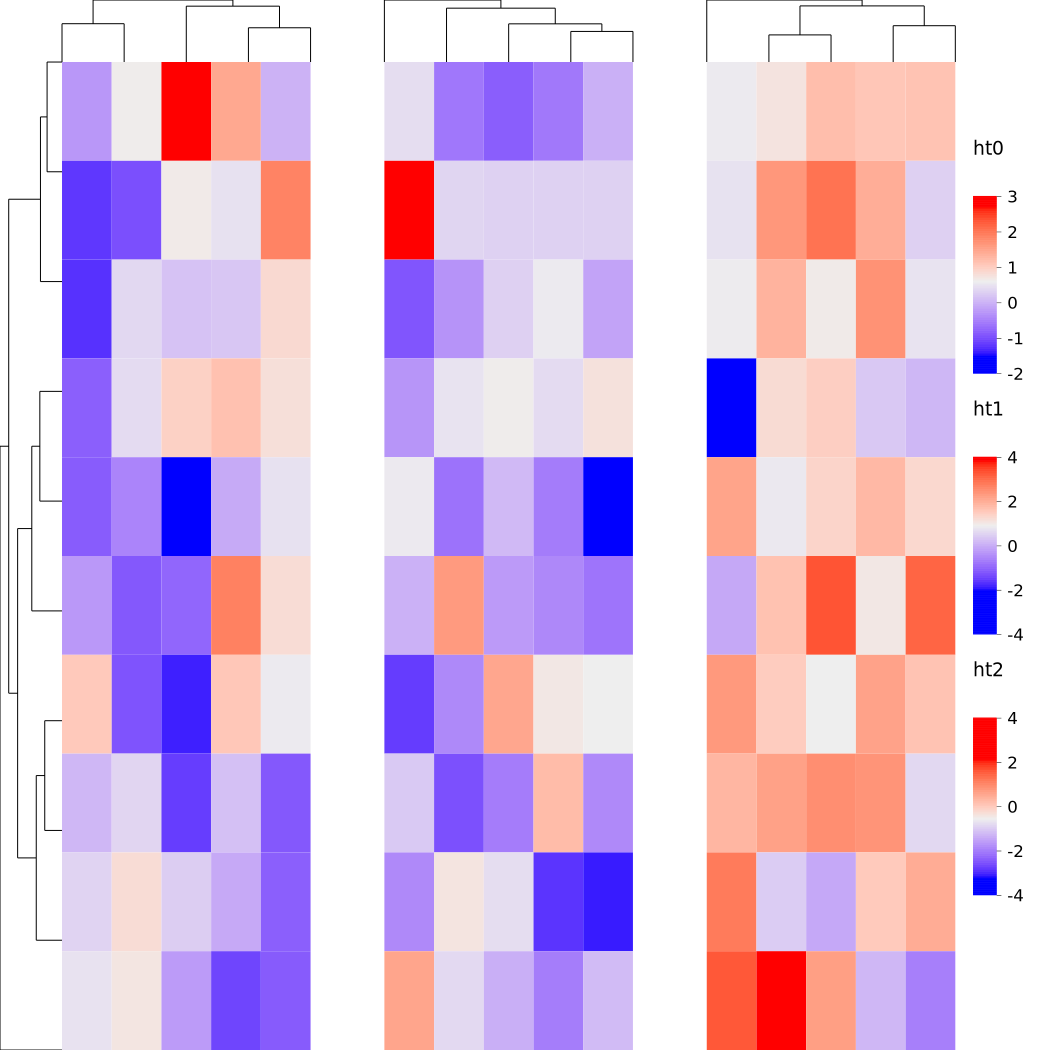

HeatmapList(['ht0', 'ht1', 'ht2'], direction='horizontal')

In [13]:
ht_list = None
for i in range(3):
    m = np.random.randn(10, 5)
    ht_list = ht_list + Heatmap(m, name=f"ht{i}")

print(f"Type: {type(ht_list).__name__}")
ht_list.draw()

## Summary

This tutorial covered:

- Horizontal concatenation of heatmaps with `+`
- `HeatmapList` explicit construction with `add_heatmap`
- Global titles via `draw(row_title=..., column_title=...)`
- Gaps between heatmaps with `ht_gap`
- Main heatmap concept: controls global row ordering and splitting
- Changing the main heatmap with `main_heatmap`
- Concatenating annotations with heatmaps
- Controlling heatmap widths
- Loop-based construction with `None + Heatmap(...)`